# Food Recipes Project
### By Brayden Davies


In this session we will run code answering our research question:

What patterns of user satisfaction and review themes can be identified from
the top recipes that are quick and easy, based on most common review words at each rating group?

We will be using MapReduce, GroupBy, Cosine similarity and TF-IDF algorithms to run this and help find results for our research question. We have added NLTK and Part of Speech (POS) to help find our most common words. This will apply with the overall concept of content-based recommendation.

This Project is done by a parallel computing than sequential. We are using Dask to run this project.

API for Dask Dataframe: https://docs.dask.org/en/stable/dataframe-api.html

Note: This project will take a long time but quicker if run on VS Code so fair warning, that is if you do run it yourself.


## 1) Import the data

In [1]:
import sys
print(sys.version)

3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


### Import Dask, Matplotlib, TF-IDF and Numpy

In [1]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from warnings import filterwarnings
filterwarnings('ignore')

### Download and Import NLTK

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk import pos_tag

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('tagsets_json', quiet=True)

True

Here are list of words in stopwords

In [3]:
stop_words = set(stopwords.words('english'))
custom_words = {'recipe', 'also', 'really', 'thanks', 'used', 'made', 'would', 'make', 'didnt', 'little', 'still'}
stop_words = custom_words.union(stop_words)
print(stop_words)

{'doesn', 'isn', 'where', 'above', 'yours', "you've", 'couldn', 'with', 'in', 'didnt', 'have', 'i', 'few', 'no', "shouldn't", "couldn't", "doesn't", 'they', 'very', 'll', 'the', 'ain', 'yourselves', "isn't", 'had', 'under', 'are', 'ours', "he's", "we've", 'while', 'recipe', 'd', 'him', 'there', 'over', "i'll", 're', 'wasn', 'she', 'why', 'these', "you'll", 'made', 'make', 'itself', 'those', 'been', 'but', "he'd", 'at', 'once', 'on', 'ourselves', 'y', "mustn't", "she'd", 'here', 'not', 'and', 'be', 'were', 'did', 'only', 'having', "don't", 'its', 'won', "you're", 'himself', 'shouldn', 'an', 'mightn', 'so', "it'll", "hasn't", 'against', 'mustn', "he'll", "haven't", 'is', 'both', 'don', 'also', 'it', 'or', "didn't", 'as', 'themselves', 'below', 'we', 'o', 'such', 'really', 'thanks', "aren't", 'which', 'has', 'nor', 'how', 'still', 'our', 'this', 'to', "we're", 'shan', 'than', 'of', "i'd", 'because', 'then', 'up', 'being', "hadn't", 'a', "wasn't", 'hasn', 'out', 'can', "we'll", "weren't", 

Here are the meanings and example of the POS

In [ ]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

### Import from Kaggle

Using Kagglehub to download the data.

Link: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

Datasets: RAW_interactions.csv and RAW_recipes.csv

Reference: Generating Personalized Recipes from Historical User Preferences
Bodhisattwa Prasad Majumder*, Shuyang Li*, Jianmo Ni, Julian McAuley
EMNLP, 2019

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")

print("Path to dataset files:", path)

Path to dataset files: /Users/braydendavies/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2


In [5]:
import os
raw_interactions_df = dd.read_csv(os.path.join(path, 'RAW_interactions.csv'))
raw_recipes_df = dd.read_csv(os.path.join(path, "RAW_recipes.csv"))

## 2) Testing the datasets

In [ ]:
raw_interactions_df.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [ ]:
raw_recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [ ]:
print("Number of Interaction rows:", len(raw_interactions_df))
print("=========================")
print("Number of Recipe rows:", len(raw_recipes_df))

Number of Interaction rows: 1132367
Number of Recipe rows: 231637


## 3) Data Preprocessing

### Merge Both Datasets together

In [6]:
#rename a column to match both of them together
raw_recipes_df = raw_recipes_df.rename(columns={'id': 'recipe_id'})
recipe_reviews = raw_interactions_df.merge(raw_recipes_df, left_on='recipe_id',right_on='recipe_id',how='inner')
recipe_reviews.head()

,user_id,recipe_id,date,rating,review,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,345234,312813,2008-08-06,5,I was looking for a way to use up my canned ca...,grandmas carrot cake,80,373940,2008-07-08,"['time-to-make', 'course', 'preparation', 'des...","[936.4, 83.0, 341.0, 30.0, 16.0, 102.0, 35.0]",13,['drain the carrots and mash them in large bow...,my grandmother jake recently passed away and i...,"['eggs', 'sugar', 'vegetable oil', 'flour', 'b...",17
1,667364,315678,2008-08-20,0,"In Indiana, we microwave the corn in the husk ...",2 minute corn on the cob,3,167527,2008-07-25,"['lactose', '15-minutes-or-less', 'time-to-mak...","[87.7, 2.0, 25.0, 0.0, 6.0, 1.0, 6.0]",5,['take the outer layer of the husk off of the ...,you will be amazed at how corn on the cob whic...,"['ear of corn', 'paper']",2
2,73773,315678,2009-02-14,5,Super easy and super tasty. Much easier and qu...,2 minute corn on the cob,3,167527,2008-07-25,"['lactose', '15-minutes-or-less', 'time-to-mak...","[87.7, 2.0, 25.0, 0.0, 6.0, 1.0, 6.0]",5,['take the outer layer of the husk off of the ...,you will be amazed at how corn on the cob whic...,"['ear of corn', 'paper']",2
3,548189,255756,2007-10-08,4,My husband loved this! I thought it was great ...,spicy dorito chicken casserole,20,542773,2007-09-26,"['30-minutes-or-less', 'time-to-make', 'course...","[307.3, 29.0, 7.0, 32.0, 22.0, 34.0, 7.0]",7,"['cook chicken through', 'add all spices to th...",this recipe is something i made up when we ran...,"['chicken breast halves', 'chili powder', 'gar...",12
4,611857,255756,2007-10-19,3,We loved this. Make sure to save your extra so...,spicy dorito chicken casserole,20,542773,2007-09-26,"['30-minutes-or-less', 'time-to-make', 'course...","[307.3, 29.0, 7.0, 32.0, 22.0, 34.0, 7.0]",7,"['cook chicken through', 'add all spices to th...",this recipe is something i made up when we ran...,"['chicken breast halves', 'chili powder', 'gar...",12


### Exploratory Data Analysis

We will look at some exploration of the dataset to see what we are trying to look for.

In [9]:
print(recipe_reviews['rating'].value_counts().compute())
print("=====================")
print(recipe_reviews['name'].value_counts().nlargest(10).compute())
print("=====================")
print("Number of Unique Users:", recipe_reviews['user_id'].nunique().compute())
print("=====================")
print(recipe_reviews.isnull().sum().compute())

rating
0     60847
3     40855
5    816364
2     14123
1     12818
4    187360
Name: count, dtype: int64
name
best banana bread                                    1614
to die for crock pot roast                           1601
crock pot chicken with black beans   cream cheese    1579
creamy cajun chicken pasta                           1448
best ever banana cake with cream cheese frosting     1322
yes  virginia there is a great meatloaf              1305
jo mama s world famous spaghetti                     1234
whatever floats your boat  brownies                  1220
kittencal s italian melt in your mouth meatballs      997
japanese mum s chicken                                904
Name: count, dtype: int64[pyarrow]
Number of Unique Users: 226570
user_id               0
recipe_id             0
date                  0
rating                0
review              169
name                  1
minutes               0
contributor_id        0
submitted             0
tags                  0
nutr

### Cleaning and Filtering

Cleaning the dataset so we have what we needed for our analysis. Filter columns that we only need. Lowercase the words in the review column to make the word count easier to run. Remove the rating group 0 and finally dropping rows with missing values or data.

In [7]:
recipe_reviews = recipe_reviews[['name', 'recipe_id', 'rating', 'review', 'minutes']]
recipe_reviews['review'] = recipe_reviews['review'].fillna('').str.lower()
recipe_reviews['review'] = recipe_reviews['review'].str.replace(r'[^a-zA-Z ]', '', regex=True)
recipe_reviews = recipe_reviews[recipe_reviews['rating'] != 0]
recipe_reviews = recipe_reviews.dropna()
recipe_reviews.head()

,name,recipe_id,rating,review,minutes
0,devilicious cookie cake delights,44394,4,this worked very well and is easy i used not ...,20
1,lamb stew with tomatoes chickpeas and spices,200236,4,we really enjoyed this and so did both my youn...,150
2,lamb stew with tomatoes chickpeas and spices,200236,4,this is an excellent got lamb and a tin of chi...,150
3,lamb stew with tomatoes chickpeas and spices,200236,5,this was a lovely morrocan style dish i halved...,150
4,lamb stew with tomatoes chickpeas and spices,200236,5,i love lamb stew and usually make an irish ver...,150


Now we filter the data to answer our research questions. Recipes that take less or equal than 20 minutes.

In [8]:
#how much data we have before we filtered the dataset with 20 minutes or less recipes
#and after the previous section of code
print("Number of Rows before filtering:", len(recipe_reviews))

print("======================================")

#raw recipes dataset. give me the relevant columns and only having less than 20 minute recipes
recipe_reviews = recipe_reviews[recipe_reviews['minutes'] <= 20]

#how much data we have after the preprocessing
print("Number of Rows after filtering:", len(recipe_reviews))

Number of Rows before filtering: 1071520
Number of Rows after filtering: 270170


### Export the Dataset we have now into a csv for saving

In [ ]:
#recipe_reviews.compute().to_excel('recipe_reviews.xlsx', index=False)

The csv is then used for our Exploratory Data Analysis in a different programming tool. I have used Tableau to create a dashboard with charts, plots and distributions. 

## 4) Algorithm Implementation

Here is the algorithm implementation section for this project. We will be implementing MapReduce, Groupby, Cosine similarity, and TF-IDF.

### 1) Word Frequencies and MapReduce


We could do this with or without using the NLTK however the results would be less good for the rest of the implementation. So here is what it would look like without using NLTK.

In [ ]:
#word processing
def extract_words(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tagged = pos_tag(tokens)
    return tagged

#using MapReduce
recipe_reviews['word'] = recipe_reviews.map_partitions(
    lambda x: x['review'].map(extract_words),meta=('word', 'object'))

recipe_reviews.head()

,name,recipe_id,rating,review,minutes,word
112,french style peas,98532,5,a recipe so simple to cook gave us the sweetes...,20,"[(recipe, NN), (simple, JJ), (cook, NN), (gave..."
113,french style peas,98532,5,this is excellent i had this decades ago over...,20,"[(excellent, JJ), (decades, NNS), (ago, IN), (..."
114,french style peas,98532,4,resist the urge to add more water to this reci...,20,"[(resist, NN), (urge, NN), (add, VBP), (water,..."
115,french style peas,98532,4,very nice the peas turned out sweet and tende...,20,"[(nice, JJ), (peas, NNS), (turned, VBD), (swee..."
116,french style peas,98532,5,neat way to cook the peas i really loved how t...,20,"[(neat, JJ), (way, NN), (cook, NN), (peas, NNS..."


In [ ]:
#word processing
def extract_words(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

#using MapReduce
recipe_reviews['word'] = recipe_reviews.map_partitions(
    lambda x: x['review'].map(extract_words),meta=('word', 'object'))

#explodes the dataset so we get one row is one word
word_df = recipe_reviews[['rating', 'word']].explode('word')
word_df = word_df.dropna(subset=['word'])
word_df = word_df[word_df['word'].str.strip() != '']

#does a count for us
word_counts = word_df.groupby(['rating', 'word']).size().to_frame('counts').reset_index()

#gives top ten
top_words = (word_counts.map_partitions(lambda x: x.sort_values('counts', ascending = False))
    .groupby('rating').head(10).compute())

#set this into a dataframe that we can merge with the merged reviews later
vectors_per_rating_df = top_words.groupby('rating')['word'].agg(lambda x: list(x)).reset_index()
vectors_per_rating_df.head()

,rating,word
0,1,"[recipe, like, taste, didnt, made, would, make..."
1,2,"[recipe, like, didnt, taste, would, make, much..."
2,3,"[recipe, good, would, like, made, make, used, ..."
3,4,"[recipe, made, used, good, thanks, make, time,..."
4,5,"[recipe, made, used, thanks, great, make, good..."


The words are basic and less quality relating to review words for recipes. Therefore, we have to use NLTK.

Here is the section of and results for our top 10 common words per rating group uisng NLTK and part of speech (POS) where we want descriptive words featured in the dataset.

We have used filtered aspects of the POS using any with JJ and RR as well as VBD and VBG. These aspected POS are the best quality for our common words.

Reference: Part of Speech Tagging with Stop words using NLTK in python - GeeksforGeeks. (2018, February 2). GeeksforGeeks. https://www.geeksforgeeks.org/part-speech-tagging-stop-words-using-nltk-python/

In [9]:
#word processing
def extract_words(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tagged = pos_tag(tokens)
    filtered = [word for word, pos in tagged if (pos.startswith('JJ') or pos == 'VBD' or pos == "VBG" or pos.startswith('RB'))]
    return filtered

#using MapReduce
#############################################################################
recipe_reviews['word'] = recipe_reviews.map_partitions(
    lambda x: x['review'].map(extract_words),meta=('word', 'object'))

#explodes the dataset so we get one row is one word
word_df = recipe_reviews[['rating', 'word']].explode('word')
word_df = word_df.dropna(subset=['word'])
word_df = word_df[word_df['word'].str.strip() != '']
#############################################################################

#does a count for us
word_counts = word_df.groupby(['rating', 'word']).size().to_frame('counts').reset_index()

#gives top ten
top_ten_words = (word_counts.map_partitions(lambda x: x.sort_values('counts', ascending = False))
    .groupby('rating').head(10).compute())

print(top_ten_words)


       rating       word  counts
819         1       much     490
561         1       good     482
418         1       even     431
11          1      added     247
1373        1      tried     244
502         1   followed     214
423         1    exactly     211
778         1      maybe     197
115         1     better     194
843         1      never     190
2305        2       much     627
2047        2       good     551
1526        2      added     338
1919        2       even     332
2258        2      maybe     329
1621        2     better     278
2918        2       well     250
2736        2      sweet     232
2062        2      great     224
1913        2     enough     189
3971        3       good    3049
4492        3       much    1593
3006        3      added    1399
4537        3       next    1030
3692        3       easy    1026
4405        3      maybe     967
3985        3      great     952
3175        3     better     862
4538        3       nice     825
5662      

#### Set the top words into a dataframe

In [10]:
#set this into a dataframe that we can merge with the merged reviews later
vectors_per_rating_df = top_ten_words.groupby('rating')['word'].agg(lambda x: list(x)).reset_index()
vectors_per_rating_df['word'] = vectors_per_rating_df['word'].map(lambda x: ' '.join(x))
vectors_per_rating_df.head()

,rating,word
0,1,much good even added tried followed exactly ma...
1,2,much good added even maybe better well sweet g...
2,3,good much added next easy maybe great better n...
3,4,good great added easy nice next much instead w...
4,5,great good easy delicious added much loved sha...


#### Combine reviews with recipe and rating

In [11]:
#combining every review to its rating and recipe
merged_reviews = recipe_reviews.groupby(['name', 'rating', 'minutes'])['review'].sum().reset_index()
merged_reviews.head()

,name,rating,minutes,review
0,1 2 3 black bean salsa dip,5,5,great recipe ive made this a couple of times ...
1,1 2 3 hot chocolate,4,12,a good way to make hot chocolate if you dont h...
2,1 easiest dr pepper ham glaze ever,5,13,i was looking for something new to do to my ea...
3,1 minute no bake cocoa delicacy,1,6,i followed this to the letter and i ended up w...
4,1 minute no bake cocoa delicacy,5,6,just delicious but what i liked most was the s...


In [ ]:
print(len(merged_reviews))

87298


#### Create a dataframe where we have everything

In [12]:
joined_df = merged_reviews.merge(vectors_per_rating_df, on='rating')
joined_df.head()

,name,rating,minutes,review,word
0,1 2 3 black bean salsa dip,5,5,great recipe ive made this a couple of times ...,great good easy delicious added much loved sha...
1,1 2 3 hot chocolate,4,12,a good way to make hot chocolate if you dont h...,good great added easy nice next much instead w...
2,1 easiest dr pepper ham glaze ever,5,13,i was looking for something new to do to my ea...,great good easy delicious added much loved sha...
3,1 minute no bake cocoa delicacy,1,6,i followed this to the letter and i ended up w...,much good even added tried followed exactly ma...
4,1 minute no bake cocoa delicacy,5,6,just delicious but what i liked most was the s...,great good easy delicious added much loved sha...


In [ ]:
print(len(joined_df))

87298


### 2) TF-IDF and Cosine similarity.

We will use this to find the most recommended recipes based on the 10 most common words in the vectors. Here it will help answer our research question for what patterns and themes can be identified from the top recipes based on most common words. Once we get recommendations we can identify what words were in the recommendations and see why they are in the top ten.

References:

Scikit learn. (2018). TfidfVectorizer. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

Cosine Similarity code from the quiz server: https://quiz2025.csse.canterbury.ac.nz/mod/quiz/review.php?attempt=21323&cmid=1885 <-- Won't be able to access this

#### a. This version gives us comparing the common words with every word in the review text per row.

In [13]:
#cosine similarity algorithm
def cosine_similarity(u, v):
   return np.dot(u, v) / np.sqrt((np.sum(u**2) * np.sum(v**2)))

#def cosine_similarity(u, v):
 #   u, v = np.array(u), np.array(v)
 #   if u.size == 0 or v.size == 0:
 #       return 0.0
 #   return float(np.dot(u, v) / np.sqrt(np.sum(u**2) * np.sum(v**2)))

#def cosine_similarity(u, v):
 #   u, v = np.array(u), np.array(v)
 #   denominator = np.sqrt(np.sum(u**2) * np.sum(v**2))
  #  if denominator == 0:
  #      return 0.0
 #   return float(np.dot(u, v) / denominator)

def compute_similarity(review, words):
    tfidf = TfidfVectorizer(stop_words='english')
    vectors = tfidf.fit_transform([review, words]).toarray()
    return cosine_similarity(vectors[0], vectors[1])

def apply_similarity(df):
    df['similarity'] = df.apply(
        lambda row: compute_similarity(row['review'], row['word']), axis=1)
    return df

version_1 = joined_df.map_partitions(
    apply_similarity,
    meta={
        'name': 'object',
        'rating': 'int64',
        'minutes': 'int64',
        'review': 'object',
        'word': 'object',
        'similarity': 'f8'})

result = version_1.compute()
print(result[['name', 'rating', 'similarity']].head())

                                  name  rating  similarity
0           1 2 3 black bean salsa dip       5    0.256376
1                  1 2 3 hot chocolate       4    0.072441
2  1 easiest dr  pepper ham glaze ever       5    0.092317
3    1 minute  no bake  cocoa delicacy       1    0.054004
4    1 minute  no bake  cocoa delicacy       5    0.063355


In [14]:
#finds the common words in each recipe
print("Recommendations:")

def get_common_words(review, common_words):
    overlap = set(review.split()) & set(common_words.split())
    return ", ".join(sorted(overlap)) if overlap else "None"

version_1['matching_words'] = version_1.map_partitions(
    lambda df: df.apply(lambda row: get_common_words(row['review'], row['word']), axis=1),
    meta=('matching_words', 'object'))
result = version_1[version_1['matching_words'] != "None"]

#top_similar_per_rating = result.groupby('rating', group_keys=False).apply(
#    lambda df: df.nlargest(10, 'similarity'), meta=version_1._meta).compute().reset_index(drop=True)

top_similar_per_rating = (result.compute().sort_values('similarity', ascending=False)
            .groupby('rating').head(10).reset_index(drop=True))

#presentable output/recommendations
def format_group(group):
    result = f"\nTop 10 Similar Recipes for {group.name}-Star Reviews:\n"
    selected = group[['name', 'minutes', 'similarity', 'matching_words']]
    result += selected.to_string(index=False)
    return result

result = top_similar_per_rating.groupby('rating').apply(format_group, include_groups=False)
print("\n".join(result.tolist()))

Recommendations:

Top 10 Similar Recipes for 1-Star Reviews:
                                                          name  minutes  similarity                                                          matching_words
                                              perfect meringue       20    0.278943                                                                    good
                                  chocolate flax seed porridge       15    0.278943                                                                    good
creamed carrots  recipe from the titanic  ship   not the movie        6    0.278943                                                                    good
                                      broiled tilapia parmesan       15    0.237903                                                       exactly, followed
             candied sugared almonds  german gebrannte mandeln       20    0.225601                                            better, exactly, good, tried
   

##### Plots for Results

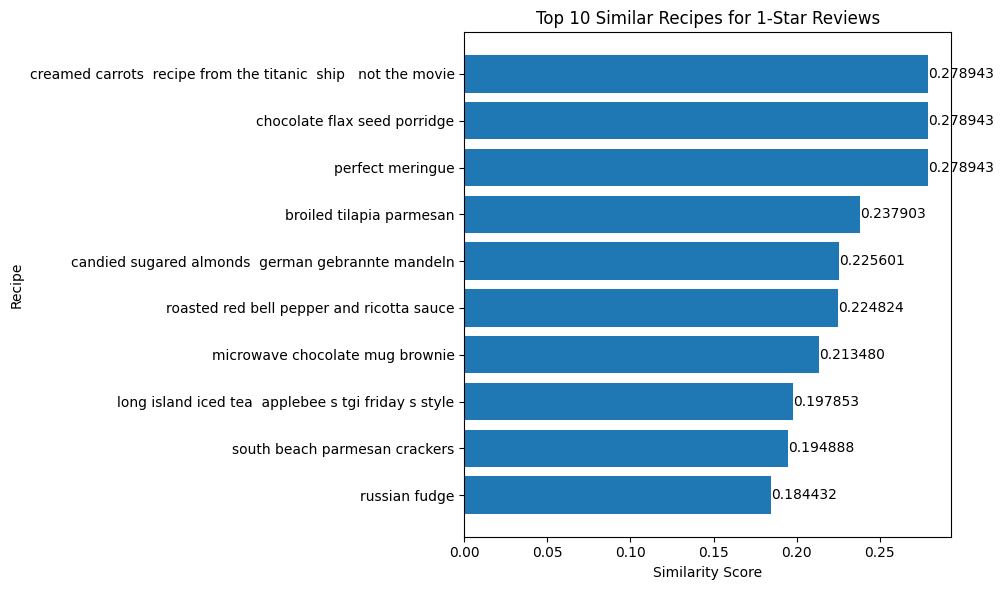

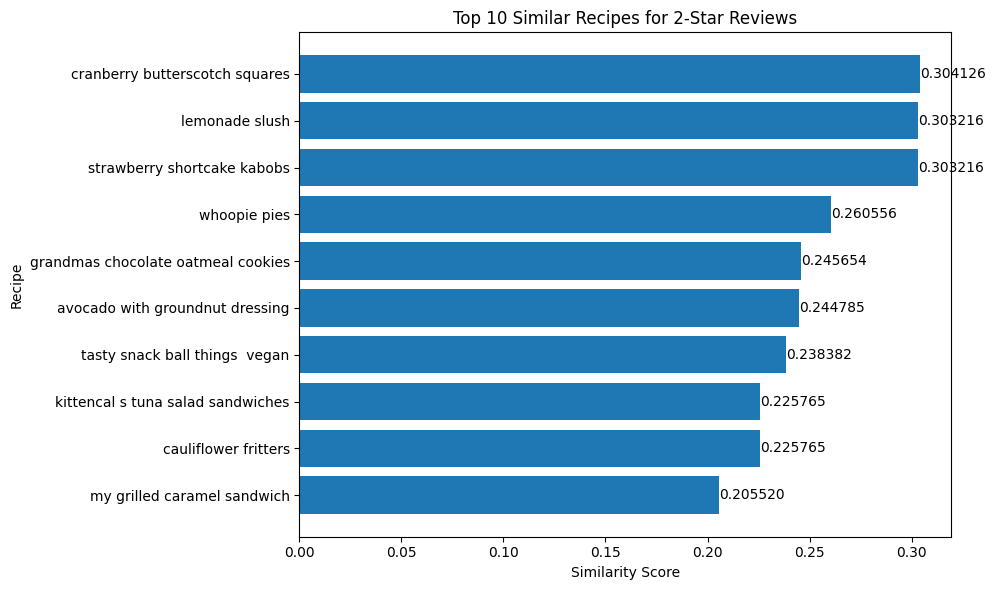

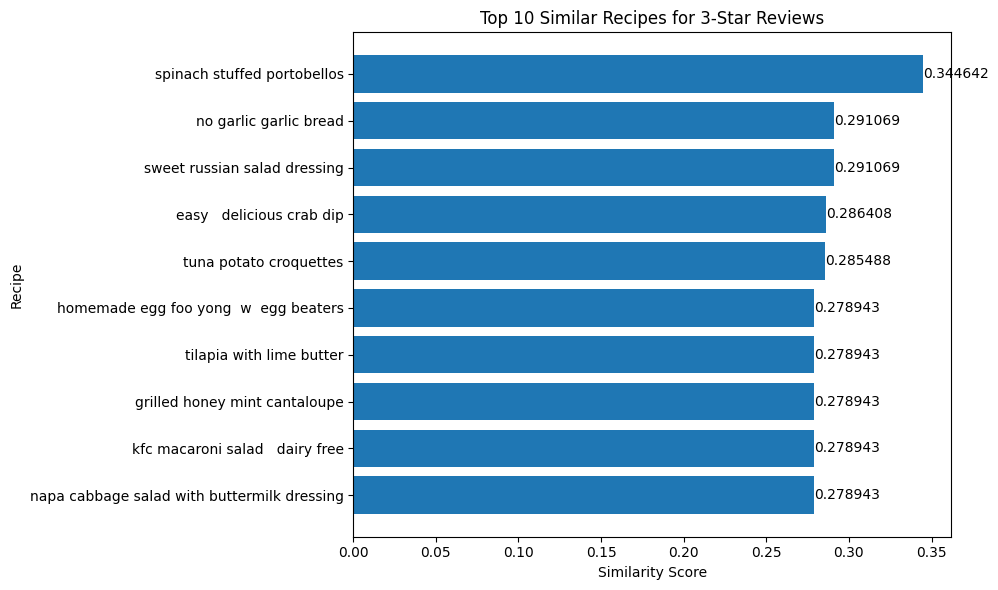

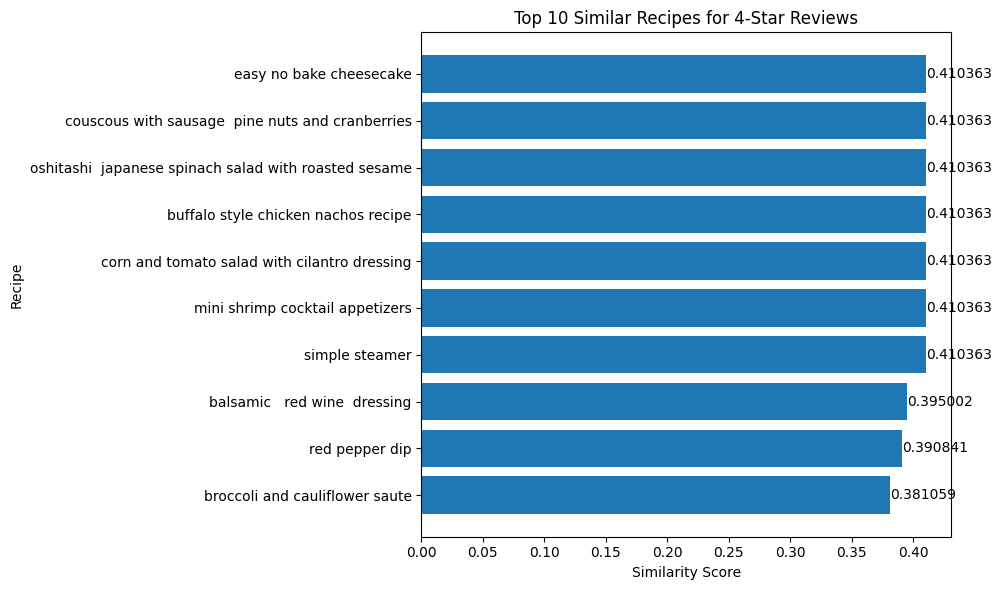

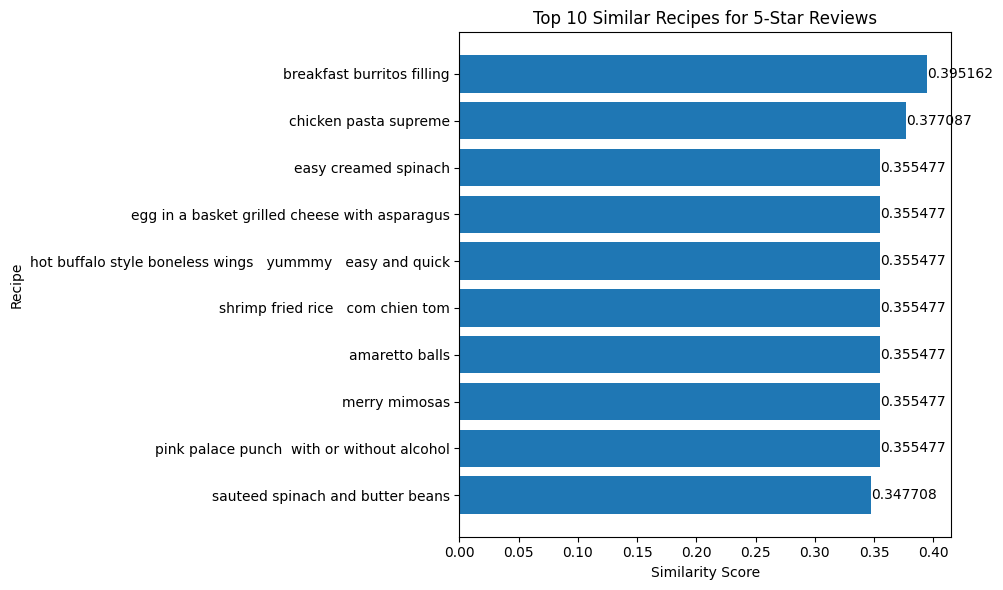

In [15]:
#presentable output/recommendations
for rating, group in top_similar_per_rating.groupby('rating'):
    group = group.sort_values('similarity')
    plt.figure(figsize=(10, 6))
    bars = plt.barh(group['name'],group['similarity'])

    plt.xlabel('Similarity Score')
    plt.ylabel('Recipe')
    plt.title(f'Top 10 Similar Recipes for {rating}-Star Reviews')

    for bar in bars:
        plt.text(bar.get_width(),bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.6f}',va='center')

    plt.tight_layout()
    plt.show()

#### b. This version gives us comparing the common words with only the common words in the review text.

In [16]:
#cosine similarity algorithm
def cosine_similarity2(u, v):
     return np.dot(u, v) / np.sqrt((np.sum(u**2) * np.sum(v**2)))

def compute_similarity2(review, common_words):
    common_words = set(common_words.split())
    review_words = review.split()
    filtered = [word for word in review_words if word in common_words]

    if not filtered or not common_words:
        return 0.0

    filtered_review = " ".join(filtered)

    tfidf = TfidfVectorizer(vocabulary=list(common_words))
    vectors = tfidf.fit_transform([filtered_review, " ".join(common_words)]).toarray()
    return cosine_similarity2(vectors[0], vectors[1])

def apply_similarity2(df):
    df['similarity'] = df.apply(
        lambda row: compute_similarity2(row['review'], row['word']), axis=1)
    return df

#merge both the merged reviews and common words together to easily implement
#TF-IDF and cosine similarity
version_2 = joined_df.map_partitions(
    apply_similarity2,
    meta={
        'name': 'object',
        'rating': 'int64',
        'minutes': 'int64',
        'review': 'object',
        'word': 'object',
        'similarity': 'f8'})

result = version_2.compute()
print(result[['name', 'rating', 'similarity']].head())


                                  name  rating  similarity
0           1 2 3 black bean salsa dip       5    0.655488
1                  1 2 3 hot chocolate       4    0.230768
2  1 easiest dr  pepper ham glaze ever       5    0.335176
3    1 minute  no bake  cocoa delicacy       1    0.230768
4    1 minute  no bake  cocoa delicacy       5    0.230768


In [17]:
#finds the common words in each recipe
def get_common_words2(review, common_words):
    overlap2 = set(review.split()) & set(common_words.split())
    return ", ".join(sorted(overlap2)) if overlap2 else "None"

version_2['matching_words'] = version_2.map_partitions(
    lambda df: df.apply(lambda row: get_common_words2(row['review'], row['word']), axis=1),
    meta=('matching_words', 'object'))
result = version_2[version_2['matching_words'] != "None"]

#top_similar_per_rating2 = result.groupby('rating', group_keys=False).apply(
 #   lambda df: df.nlargest(10, 'similarity'), meta=version_2._meta).compute().reset_index(drop=True)

top_similar_per_rating2 = (result.compute().sort_values('similarity', ascending=False)
            .groupby('rating').head(10).reset_index(drop=True))

#presentable output/recommendations
def format_group2(group):
    result = f"\nTop 10 Similar Recipes for {group.name}-Star Reviews:\n"
    selected = group[['name', 'minutes', 'similarity', 'matching_words']]
    result += selected.to_string(index=False)
    return result

result = top_similar_per_rating2.groupby('rating').apply(format_group2, include_groups=False)
print("\n".join(result.tolist()))


Top 10 Similar Recipes for 1-Star Reviews:
                                        name  minutes  similarity                                                          matching_words
             microwave chocolate mug brownie        6    0.916448 added, better, even, exactly, followed, good, maybe, much, never, tried
                       the best ever waffles       20    0.786583 added, better, even, exactly, followed, good, maybe, much, never, tried
                     5 minute vegan pancakes       15    0.773957 added, better, even, exactly, followed, good, maybe, much, never, tried
                      spiced pumpkin waffles       15    0.755333                added, even, exactly, followed, good, maybe, much, tried
                  soft and chewy m m cookies       20    0.695357                    added, better, exactly, followed, much, never, tried
copycat french vanilla liquid coffee creamer        5    0.695357                     added, better, even, exactly, followed, go

##### Plots for Results

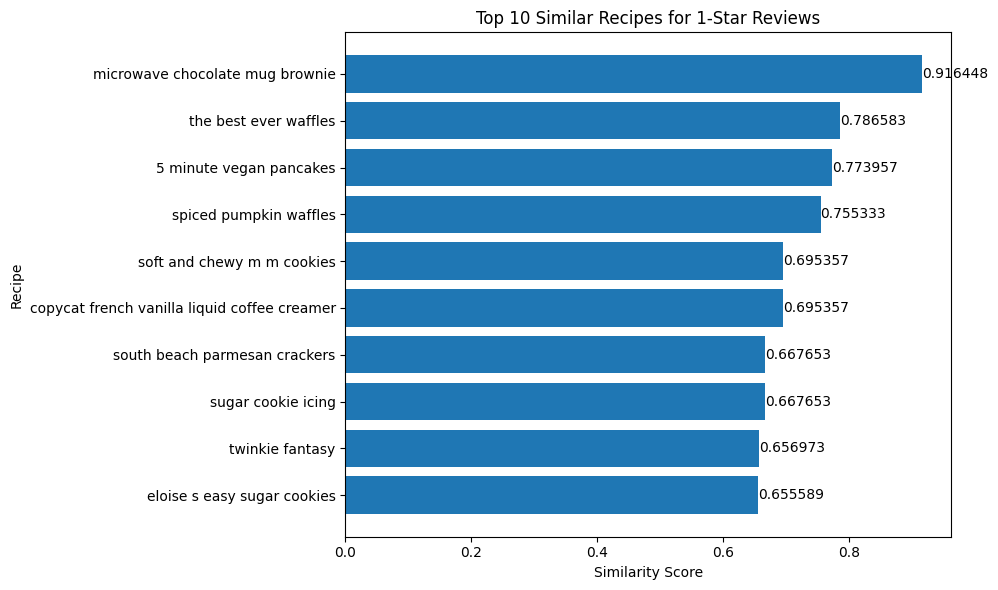

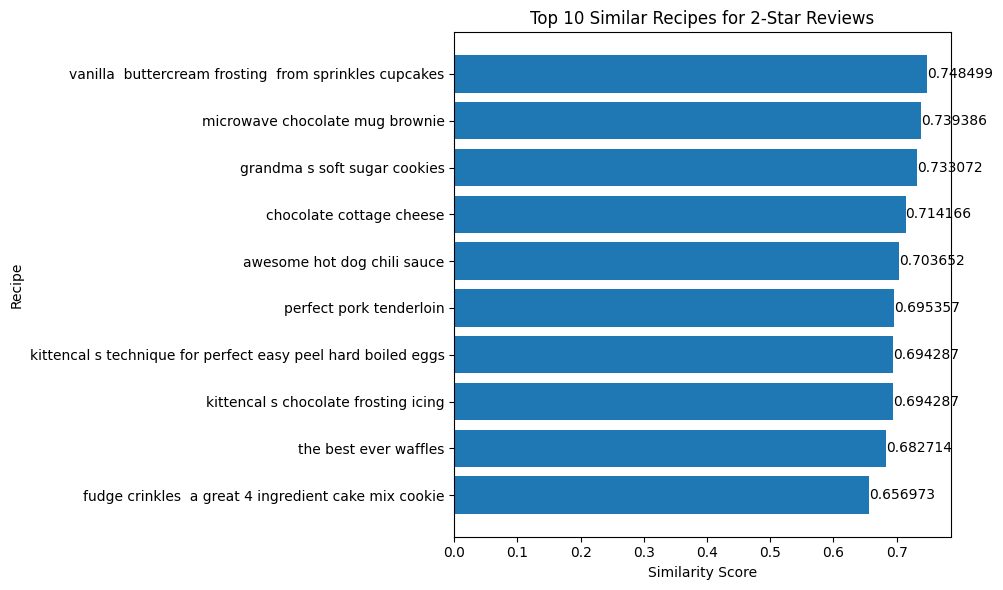

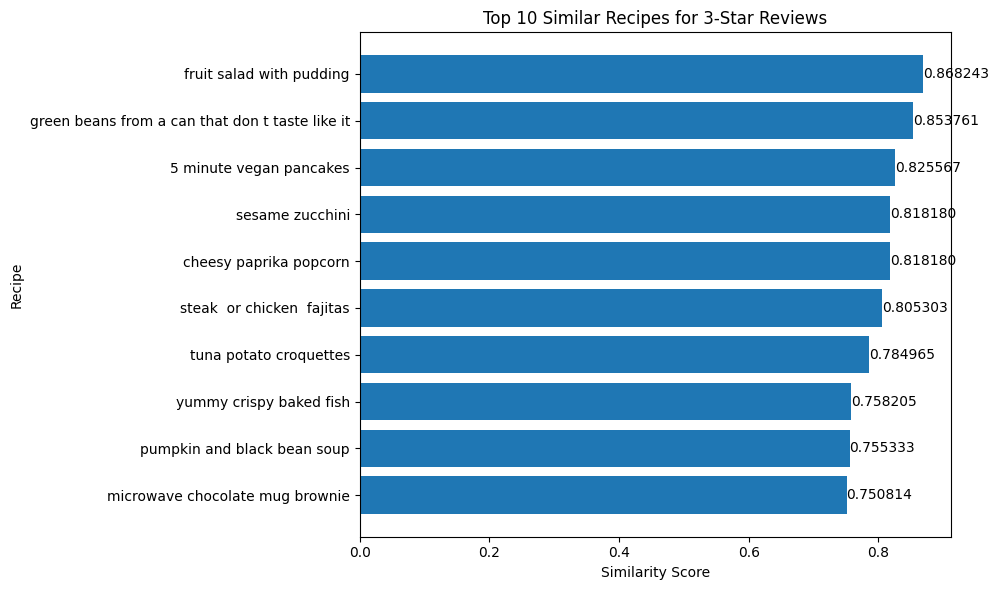

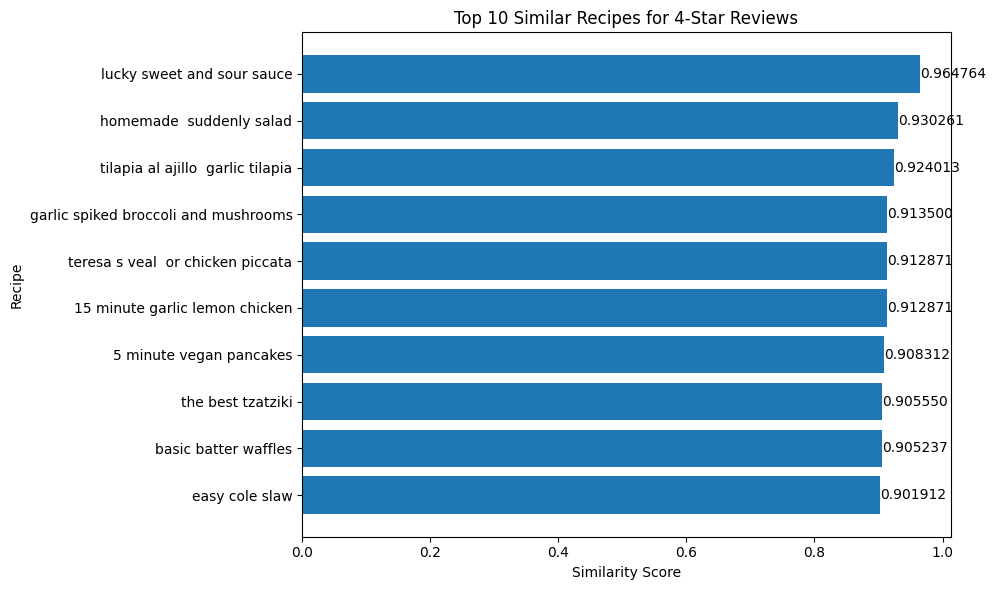

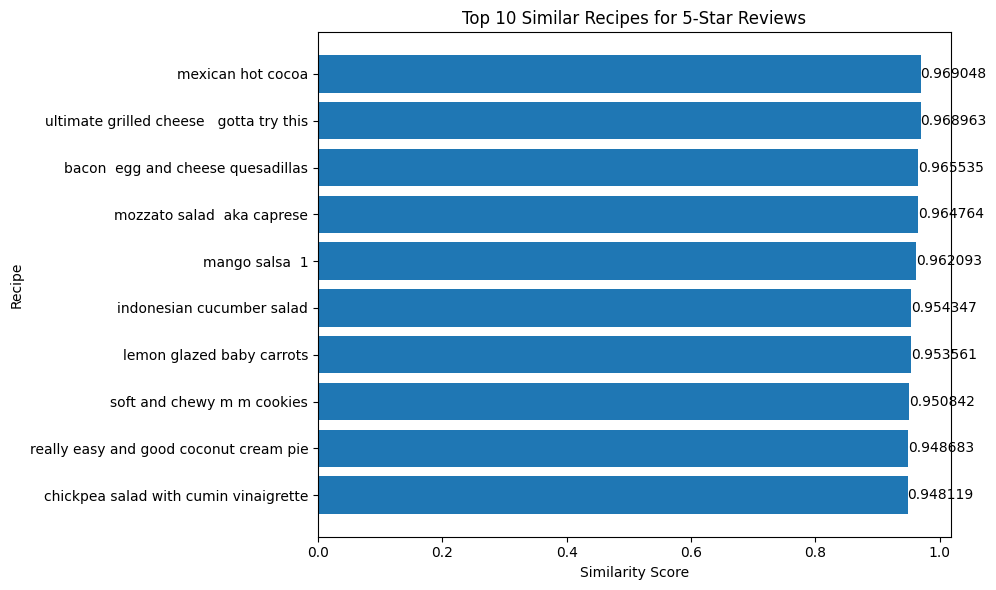

In [18]:
#presentable output/recommendations
for rating, group in top_similar_per_rating2.groupby('rating'):
    group = group.sort_values('similarity')
    plt.figure(figsize=(10, 6))
    bars = plt.barh(group['name'],group['similarity'])

    plt.xlabel('Similarity Score')
    plt.ylabel('Recipe')
    plt.title(f'Top 10 Similar Recipes for {rating}-Star Reviews')

    for bar in bars:
        plt.text(bar.get_width(),bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.6f}',va='center')

    plt.tight_layout()
    plt.show()

## 5) Results for using scalability on a single processor

### First Version

In [19]:
#we are doing the processor on the second approach for recommendation
#it probably work for both anyway

import time
import matplotlib.pyplot as plt

problem_sizes = [1000, 5000, 10000, 20000, 50000]
times = []

full_df = version_1.compute()

for size in problem_sizes:
    subset = full_df.iloc[:size].copy()

    start = time.time()
    processed = apply_similarity(subset)
    end = time.time()

    duration = end - start
    times.append(duration)
    print(f"Processed {size} rows in {duration:.2f} seconds")

Processed 1000 rows in 0.41 seconds
Processed 5000 rows in 2.03 seconds
Processed 10000 rows in 4.05 seconds
Processed 20000 rows in 8.17 seconds
Processed 50000 rows in 21.03 seconds


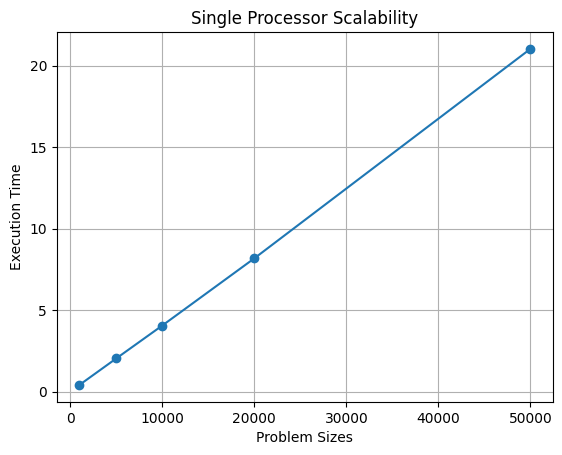

In [20]:
plt.plot(problem_sizes, times, marker='o')
plt.title("Single Processor Scalability")
plt.xlabel("Problem Sizes")
plt.ylabel("Execution Time")
plt.grid(True)
plt.show()

### Second Version

In [21]:
#we are doing the processor on the second approach for recommendation
#it probably work for both anyway

import time
import matplotlib.pyplot as plt

problem_sizes = [1000, 5000, 10000, 20000, 50000]
times2 = []

full_df2 = version_2.compute()

for size in problem_sizes:
    subset = full_df2.iloc[:size].copy()

    start = time.time()
    processed = apply_similarity2(subset)
    end = time.time()

    duration2 = end - start
    times2.append(duration2)
    print(f"Processed {size} rows in {duration2:.2f} seconds")

Processed 1000 rows in 0.19 seconds
Processed 5000 rows in 1.03 seconds
Processed 10000 rows in 2.10 seconds
Processed 20000 rows in 4.15 seconds
Processed 50000 rows in 10.45 seconds


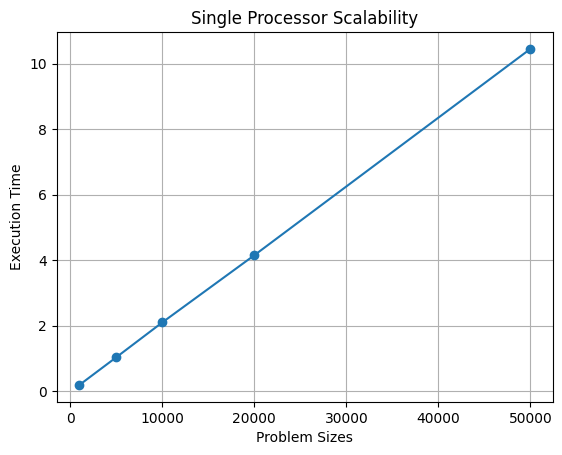

In [22]:
plt.plot(problem_sizes, times2, marker='o')
plt.title("Single Processor Scalability")
plt.xlabel("Problem Sizes")
plt.ylabel("Execution Time")
plt.grid(True)
plt.show()